In [48]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 251 (delta 43), reused 39 (delta 20), pack-reused 159 (from 1)
Receiving objects: 100% (251/251), 6.61 MiB | 21.36 MiB/s, done.
Resolving deltas: 100% (105/105), done.


In [49]:
# local files
from src import utils, plotting
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet
from src.resunet import ResUNetEncoderBlock
from src.bbbc038_dataset import BBBC038Dataset
from src.center_offset_dataset import CenterOffsetDataset

import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [51]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar
if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train

In [52]:
# O carregamento está implementado em src/bbbc038_dataset.py.
# Com is_training=True o retorno é:
# sample_id, image, semantic_mask, instance_map
IMG_SIZE = 128


In [53]:
class SharedMaxPoolEncoder(nn.Module):

    def __init__(self, in_channels=3):
        super().__init__()

        self.enc0 = ResUNetEncoderBlock(in_channels, 64, stride=1)

        self.enc1 = ResUNetEncoderBlock(64, 128, stride=1)

        self.enc2 = ResUNetEncoderBlock(128, 256, stride=1)

        self.bridge = ResUNetEncoderBlock(256, 512, stride=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

    def forward(self, x):

        out0 = self.enc0(x)
        size0 = out0.size()
        pooled0, indices0 = self.pool(out0)

        out1 = self.enc1(pooled0)
        size1 = out1.size()
        pooled1, indices1 = self.pool(out1)

        out2 = self.enc2(pooled1)
        size2 = out2.size()
        pooled2, indices2 = self.pool(out2)

        encoded = self.bridge(pooled2)

        return {
            "encoded": encoded,
            "skips": (out0, out1, out2),
            "indices": (indices0, indices1, indices2),
            "sizes": (size0, size1, size2),
        }

ID: 0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426
Antes del pooling: (1, 64, 128, 128)
Después del pooling: (1, 64, 64, 64)


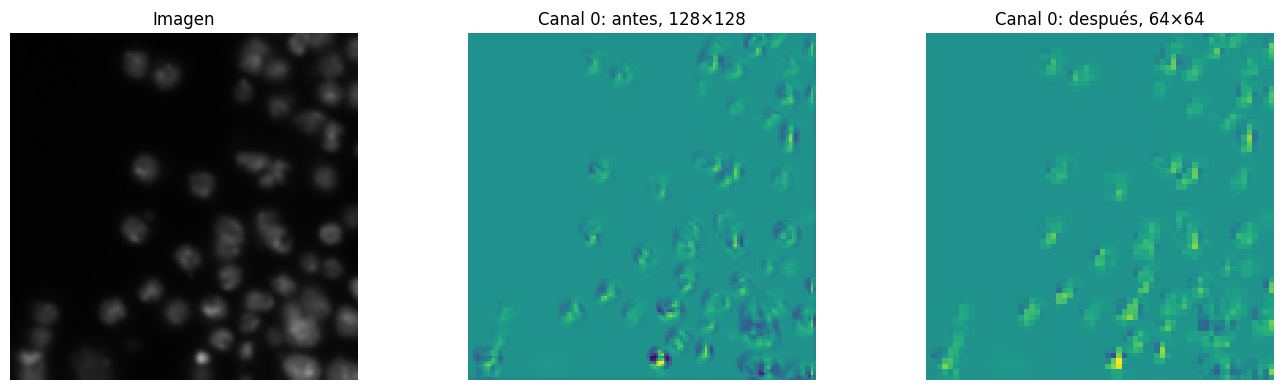

In [36]:
from pathlib import Path

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

weights_path = Path("/content/deep-learning-pa1/weights/instance_weights.zip")

model = ResUNet(3, 3).to(device)

state_dict = torch.load(
    weights_path,
    map_location=device,
    weights_only=True
)

model.load_state_dict(state_dict)
model.eval()

base_dataset = BBBC038Dataset(
    is_training=True,
    path="./data/stage1_train",
    img_size=128
)

center_dataset = CenterOffsetDataset(base_dataset)

image_id, image, heatmap, offsets, offset_mask = center_dataset[6]

pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2,
    return_indices=True
)

with torch.no_grad():

    image_batch = image.unsqueeze(0).to(device)

    features = model.enc0(image_batch)

    pooled, indices = pool(features)

print("ID:", image_id)
print("Antes del pooling:", tuple(features.shape))
print("Después del pooling:", tuple(pooled.shape))

channel = 0

before = features[0, channel].cpu().numpy()
after = pooled[0, channel].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image.permute(1, 2, 0).cpu().numpy())
axes[0].set_title("Imagen")

axes[1].imshow(
    before,
    cmap="viridis",
    vmin=before.min(),
    vmax=before.max(),
    interpolation="nearest"
)
axes[1].set_title(f"Canal {channel}: antes, 128×128")

axes[2].imshow(
    after,
    cmap="viridis",
    vmin=before.min(),
    vmax=before.max(),
    interpolation="nearest"
)
axes[2].set_title(f"Canal {channel}: después, 64×64")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [54]:
image_id, image, heatmap, offsets, offset_mask = center_dataset[6]

pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2,
    return_indices=True
)

model.eval()

with torch.no_grad():

    image_batch = image.unsqueeze(0).to(device)

    features = model.enc0(image_batch)

    pooled, indices = pool(features)


In [55]:
print("Antes:", tuple(features.shape))
print("Depois:", tuple(pooled.shape))

Antes: (1, 64, 128, 128)
Depois: (1, 64, 64, 64)


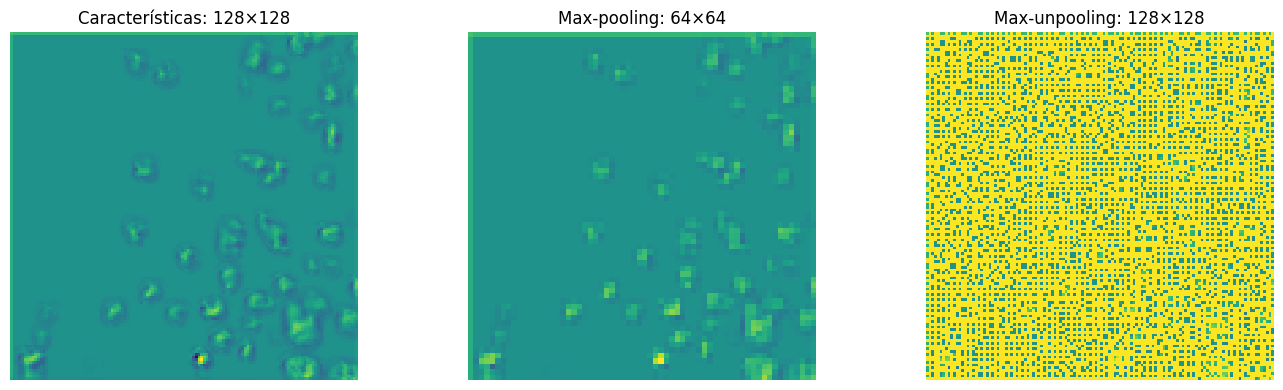

In [59]:
unpool = nn.MaxUnpool2d(
    kernel_size=2,
    stride=2
)

with torch.no_grad():
    restored = unpool(
        pooled,
        indices,
        output_size=features.size()
    )

channel = 63

before = features[0, channel].cpu().numpy()
after = pooled[0, channel].cpu().numpy()
unpooled = restored[0, channel].cpu().numpy()

vmin = min(before.min(), 0.0)
vmax = max(before.max(), 0.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, values, title in zip(
    axes,
    [before, after, unpooled],
    [
        "Características: 128×128",
        "Max-pooling: 64×64",
        "Max-unpooling: 128×128"
    ]
):
    ax.imshow(
        values,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [57]:
class MaxUnpoolDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.projection = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

        self.unpool = nn.MaxUnpool2d(
            kernel_size=2,
            stride=2
        )

        self.refine = ResUNetEncoderBlock(
            out_channels,
            out_channels,
            stride=1
        )

    def forward(self, x, indices, output_size):
        x = self.projection(x)

        x = self.unpool(
            x,
            indices,
            output_size=output_size
        )

        return self.refine(x)

In [45]:
class CenterOffsetMaxUnpool(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        self.encoder = SharedMaxPoolEncoder(
            in_channels=in_channels
        )

        self.dec2 = MaxUnpoolDecoderBlock(512, 256)
        self.dec1 = MaxUnpoolDecoderBlock(256, 128)
        self.dec0 = MaxUnpoolDecoderBlock(128, 64)

        # Canal 0: heatmap
        # Canal 1: dx
        # Canal 2: dy
        self.ending = nn.Conv2d(
            64,
            3,
            kernel_size=1
        )

    def forward(self, x):
        features = self.encoder(x)

        indices0, indices1, indices2 = features["indices"]
        size0, size1, size2 = features["sizes"]

        y = features["encoded"]

        # Recuperar resolucao
        y = self.dec2(y, indices2, size2)
        y = self.dec1(y, indices1, size1)
        y = self.dec0(y, indices0, size0)

        return self.ending(y)

In [58]:
unpool_model = CenterOffsetMaxUnpool().to(device)
unpool_model.eval()

sample_id, image, heatmap, offsets, offset_mask = center_dataset[6]

with torch.no_grad():
    prediction = unpool_model(
        image.unsqueeze(0).to(device)
    )

expected_shape = (1, 3, *image.shape[-2:])

assert tuple(prediction.shape) == expected_shape

print("ID:", sample_id)
print("Salida:", tuple(prediction.shape))
print("Heatmap:", tuple(prediction[:, 0:1].shape))
print("Offsets:", tuple(prediction[:, 1:3].shape))

ID: 0287e7ee5b007c91ae2bd7628d09735e70496bc6127ecb7f3dd043e04ce37426
Salida: (1, 3, 128, 128)
Heatmap: (1, 1, 128, 128)
Offsets: (1, 2, 128, 128)
